In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

📂 Folder penyimpanan gambar siap di: ../output/figures/cleveland/


In [2]:
# ==========================================
# FUNGSI BANTUAN (TRAINING & EVALUASI)
# ==========================================
def train_evaluate(X, y, title):
    # Split Data (80% Train, 20% Test)
    # PENTING: random_state harus sama agar perbandingan 'apple-to-apple'
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # Inisialisasi Model Decision Tree
    # criterion='entropy' atau 'gini' bebas, kita pakai entropy biar standar
    model = DecisionTreeClassifier(criterion='entropy', random_state=42)
    
    # Latih Model
    model.fit(X_train, y_train)
    
    # Prediksi
    y_pred = model.predict(X_test)
    
    # Evaluasi
    acc = accuracy_score(y_test, y_pred)
    print(f"--- HASIL MODEL: {title} ---")
    print(f"Akurasi: {acc * 100:.2f}%")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    
    # Return model dan data test untuk visualisasi nanti
    return model, acc, X_test, y_test, y_pred

In [3]:
# ==========================================
# SKENARIO 1: MENGGUNAKAN DATA MENTAH
# ==========================================
print("\n🔥 SKENARIO 1: DATA MENTAH (RAW) 🔥")
# Load Data Mentah
try:
    df_raw = pd.read_csv('../data/cleveland.csv')
    
    # --- Preprocessing Minimal (Hanya agar kode jalan) ---
    # 1. Handle Missing Value '?' (Kita buang saja biar cepat, karena ini simulasi mentah)
    df_raw = df_raw.replace('?', np.nan).dropna()
    
    # 2. Encoding Label ('A'->0, Lainnya->1)
    df_raw['target'] = df_raw['label'].apply(lambda x: 0 if x == 'A' else 1)
    
    # 3. Pisahkan X dan y
    X_raw = df_raw.drop(['label', 'target'], axis=1)
    y_raw = df_raw['target']
    
    # Jalankan Training
    model_raw, acc_raw, X_test_raw, y_test_raw, y_pred_raw = train_evaluate(X_raw, y_raw, "DATA MENTAH")
    
except Exception as e:
    print(f"Gagal memproses data mentah: {e}")
    acc_raw = 0


🔥 SKENARIO 1: DATA MENTAH (RAW) 🔥
--- HASIL MODEL: DATA MENTAH ---
Akurasi: 80.33%

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.75      0.80        32
           1       0.76      0.86      0.81        29

    accuracy                           0.80        61
   macro avg       0.81      0.81      0.80        61
weighted avg       0.81      0.80      0.80        61



In [4]:
# ==========================================
# SKENARIO 2: MENGGUNAKAN DATA BERSIH (NORMALIZED)
# ==========================================
print("\n\n✨ SKENARIO 2: DATA BERSIH & NORMALISASI ✨")
# Load Data Hasil Olahan Kita
try:
    df_clean = pd.read_csv('../data/cleveland_normalized.csv')
    
    # Data ini sudah angka semua, tinggal pisah X dan y
    # Ingat: Kolom terakhir adalah 'Target_Encoded' (atau nama lain di filemu)
    target_col = df_clean.columns[-1] # Ambil kolom terakhir otomatis
    
    X_clean = df_clean.drop(target_col, axis=1)
    y_clean = df_clean[target_col]
    
    # Jalankan Training
    model_clean, acc_clean, X_test_clean, y_test_clean, y_pred_clean = train_evaluate(X_clean, y_clean, "DATA BERSIH")

except Exception as e:
    print(f"Gagal memproses data bersih: {e}")
    acc_clean = 0



✨ SKENARIO 2: DATA BERSIH & NORMALISASI ✨
--- HASIL MODEL: DATA BERSIH ---
Akurasi: 83.61%

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.81      0.84        32
           1       0.81      0.86      0.83        29

    accuracy                           0.84        61
   macro avg       0.84      0.84      0.84        61
weighted avg       0.84      0.84      0.84        61



In [5]:
# ==========================================
# PERBANDINGAN AKHIR (SCOREBOARD)
# ==========================================
print("\n\n🏆 SCOREBOARD AKHIR 🏆")
print(f"1. Akurasi Data Mentah : {acc_raw * 100:.2f}%")
print(f"2. Akurasi Data Bersih : {acc_clean * 100:.2f}%")

improvement = acc_clean - acc_raw
if improvement > 0:
    print(f"✅ KESIMPULAN: Preprocessing berhasil meningkatkan akurasi sebesar {improvement * 100:.2f}%!")
else:
    print("ℹ️ KESIMPULAN: Akurasi sama/turun. Decision Tree memang robust terhadap data kotor.")



🏆 SCOREBOARD AKHIR 🏆
1. Akurasi Data Mentah : 80.33%
2. Akurasi Data Bersih : 83.61%
✅ KESIMPULAN: Preprocessing berhasil meningkatkan akurasi sebesar 3.28%!


📸 Gambar tersimpan: perbanngan_model.png


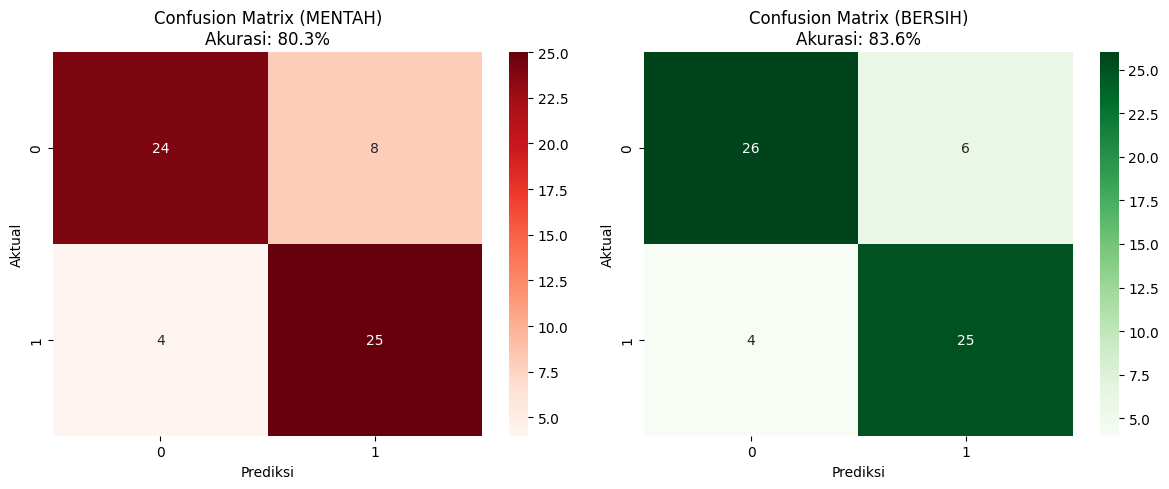

In [ ]:
# ==========================================
# VISUALISASI CONFUSION MATRIX (COMPARISON)
# ==========================================
plt.figure(figsize=(12, 5))

# Plot Mentah
plt.subplot(1, 2, 1)
sns.heatmap(confusion_matrix(y_test_raw, y_pred_raw), annot=True, fmt='d', cmap='Reds')
plt.title(f'Confusion Matrix (MENTAH)\nAkurasi: {acc_raw*100:.1f}%')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')

# Plot Bersih
plt.subplot(1, 2, 2)
sns.heatmap(confusion_matrix(y_test_clean, y_pred_clean), annot=True, fmt='d', cmap='Greens')
plt.title(f'Confusion Matrix (BERSIH)\nAkurasi: {acc_clean*100:.1f}%')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')

plt.tight_layout()
plt.show()

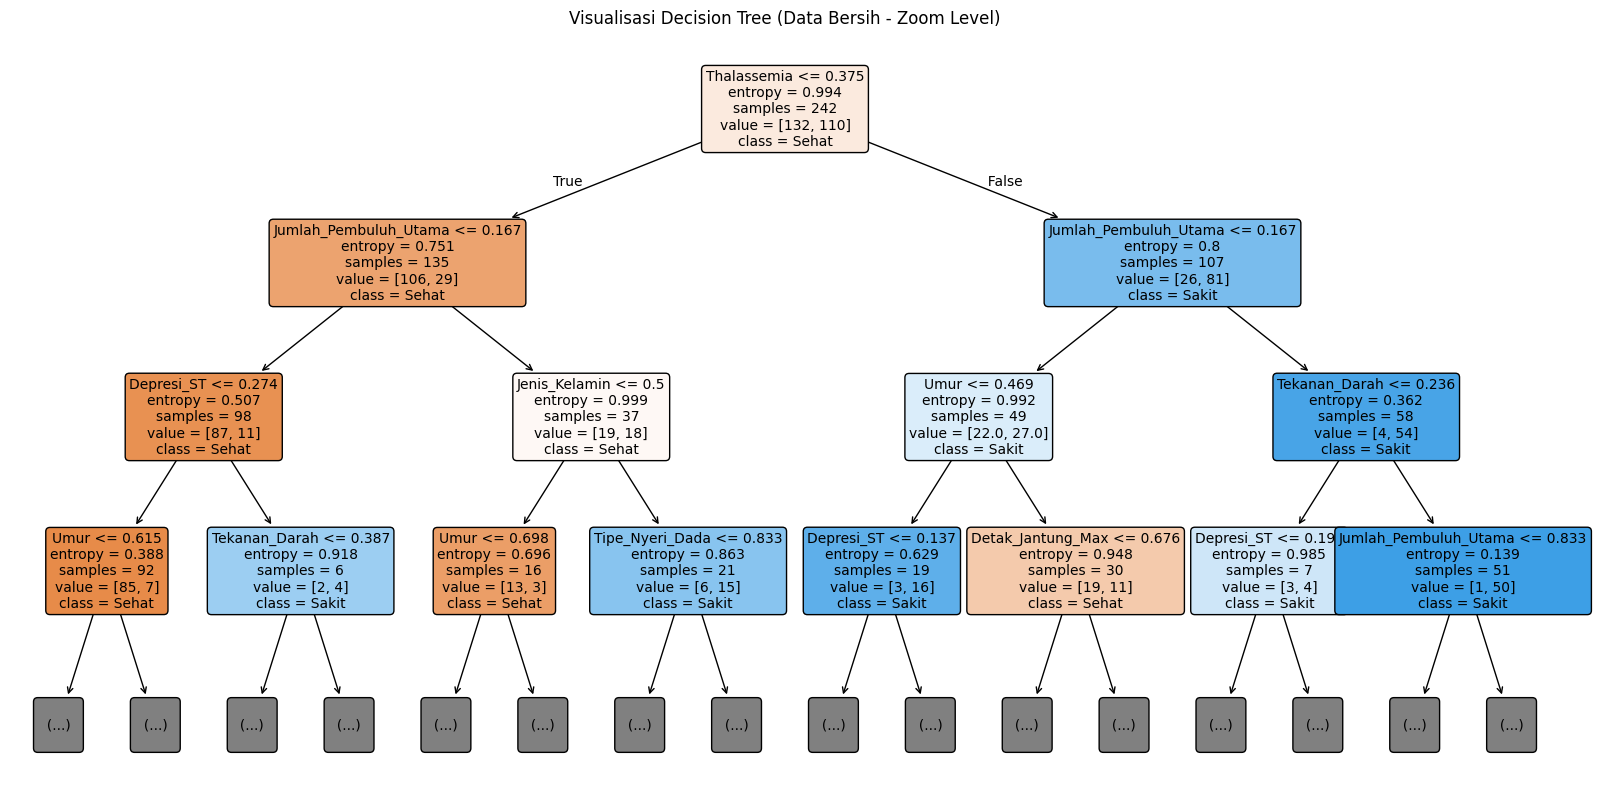

In [11]:
# ==========================================
# VISUALISASI POHON KEPUTUSAN (OPSIONAL)
# ==========================================
plt.figure(figsize=(20, 10))
plot_tree(model_clean, 
          feature_names=X_clean.columns, 
          class_names=['Sehat', 'Sakit'], 
          filled=True, 
          rounded=True,
          max_depth=3, 
          fontsize=10)
plt.title("Visualisasi Decision Tree (Data Bersih - Zoom Level)")
plt.show()